# Case Study Insights: Deep Learning for Time Series

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of temporal deep learning
(LSTM, NLinear, TSMixer, TCN, PatchTST) and contrast it with the linear
baseline (Ch11), gradient boosting (Ch12), and the tabular DL adapter TabM
(Ch12). Per-case-study deep dives live in `case_studies/{cs}/11_model_analysis.py`;
this notebook is the comparative view across the eight case studies that carry
DL pipelines.

**Learning objectives**

- For each case study, read the highest-IC DL configuration's daily-pooled
  Spearman IC with HAC 95 % CI on the primary label
- Trace the architecture × case-study coverage map and the per-architecture
  IC at the primary label
- Inspect per-fold IC distributions, checkpoint dynamics, and conformal
  coverage at the 90 % nominal level
- Quantify the DL-minus-highest-IC-tabular delta per case study with a paired-fold
  bootstrap confidence interval, and identify the diagnostic features of
  case studies where DL adds incremental signal
- Place the DL family inside the architectural-class taxonomy (recurrent,
  MLP-style, convolutional, attention)

**Book reference**: Section 13.7 (Practitioner Framework) and Section 13.9
(Cross-Case-Study Synthesis).

**Prerequisites**: each case study's per-architecture training notebooks
(`dl_lstm.py`, `dl_nlinear.py`, `dl_tsmixer.py`, `dl_tcn.py`, `dl_patchtst.py`)
have populated `run_log/registry.db` for the `deep_learning` family. The
linear, GBM, and TabM baselines come from Ch11–Ch12 pipelines.

In [1]:
"""Case Study Insights: Deep Learning — cross-case-study aggregation from the registry."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from matplotlib.lines import Line2D

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    DATASET_META,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_fold_ic_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    plot_cross_cs_forest,
    plot_multi_label_horizon,
    plot_per_fold_violin,
)
from case_studies.utils.model_analysis import (
    load_fold_metrics_from_registry,
    load_metrics_from_registry,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
FAMILY = "deep_learning"
TABULAR_BASELINES = ("linear", "gbm", "tabular_dl")
CONFORMAL_LEVEL = 0.90
N_BOOT = 1000

In [3]:
set_global_seeds(SEED)

**Architecture helper**: maps registry `config_name` values to the display
names used across every downstream table and figure so the four LSTM
variants collapse to a single `LSTM` row and the per-architecture grids
stay consistent.

In [4]:
def architecture(config_name: str) -> str:
    """Display name for a DL config_name (LSTM variants collapse to 'LSTM')."""
    if config_name.startswith("lstm"):
        return "LSTM"
    return {"nlinear": "NLinear", "tsmixer": "TSMixer", "tcn": "TCN", "patchtst": "PatchTST"}.get(
        config_name,
        config_name.upper(),
    )


ARCH_CLASS = {
    "LSTM": "recurrent",
    "NLinear": "MLP-style",
    "TSMixer": "MLP-style",
    "TCN": "convolutional",
    "PatchTST": "attention",
}

## 1. Scope and Coverage

The DL grid varies across the case studies — not every architecture trains
on every panel, and US Firm Characteristics (monthly cross-section) carries
no DL family at all. The headline metric is the daily-pooled Spearman IC
with HAC 95 % confidence interval on each case study's primary label
(`prediction_metrics.ic_mean_daily`, `ic_ci_lo`, `ic_ci_hi`, `ic_t_hac`).
The linear (Ch11), GBM (Ch12), and TabM (`tabular_dl`, Ch12) baselines are
loaded so the §5 delta is computable.

In [5]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    dl = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if dl.is_empty():
        coverage_rows.append(
            {
                "case_study": SHORT_NAMES[cs],
                "primary_label": primary,
                "dl_archs": "—",
                "n_dl_configs": 0,
            }
        )
        continue
    archs = sorted({architecture(c) for c in dl["config_name"].unique().to_list()})
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "dl_archs": ", ".join(archs),
            "n_dl_configs": dl["config_name"].n_unique(),
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("DL architecture coverage per case study (primary label):")
coverage_df

DL architecture coverage per case study (primary label):


case_study,primary_label,dl_archs,n_dl_configs
str,str,str,i64
"""ETFs""","""fwd_ret_21d""","""LSTM, NLinear, TSMixer""",3
"""Crypto""","""fwd_ret_8h""","""LSTM, NLinear, TCN""",3
"""NQ100""","""fwd_ret_15m""","""LSTM, NLinear, PatchTST, TCN""",4
"""SP500 Eq+Opt""","""fwd_ret_5d""","""LSTM, NLinear, PatchTST""",3
"""US Firms""","""fwd_ret_1m""","""—""",0
"""FX""","""fwd_ret_1d""","""LSTM, NLinear, TCN""",3
"""CME Futures""","""fwd_ret_5d""","""LSTM, NLinear""",2
"""SP500 Options""","""ret_to_expiry""","""NLinear, PatchTST""",2
"""US Equities""","""fwd_ret_1d""","""LSTM, NLinear, TSMixer""",3


In [6]:
# Architecture × CS availability matrix at the primary label
all_archs_sorted = ["LSTM", "NLinear", "TSMixer", "TCN", "PatchTST"]
avail_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    dl = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if dl.is_empty():
        for arch in all_archs_sorted:
            avail_rows.append({"short_name": SHORT_NAMES[cs], "architecture": arch, "ic": None})
        continue
    by_arch = (
        dl.with_columns(
            architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8)
        )
        .group_by("architecture")
        .agg(pl.col("ic_mean_daily").max().alias("ic"))
    )
    arch_to_ic = dict(by_arch.iter_rows())
    for arch in all_archs_sorted:
        avail_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "architecture": arch,
                "ic": arch_to_ic.get(arch),
            }
        )

avail_df = pl.DataFrame(avail_rows)
avail_pivot = avail_df.pivot(index="short_name", on="architecture", values="ic").sort("short_name")
print(
    "Highest-IC DL configuration per (case study × architecture) at the primary label "
    "(blank = architecture not trained on this case study):"
)
avail_pivot.select(["short_name", *all_archs_sorted])

Highest-IC DL configuration per (case study × architecture) at the primary label (blank = architecture not trained on this case study):


short_name,LSTM,NLinear,TSMixer,TCN,PatchTST
str,f64,f64,f64,f64,f64
"""CME Futures""",-0.00071,-0.015526,null,null,null
"""Crypto""",0.005066,0.029333,null,0.002422,null
"""ETFs""",0.05213,0.062197,0.029028,null,null
"""FX""",0.002288,0.010566,null,0.009935,null
"""NQ100""",0.00346,0.00456,null,0.000419,0.001656
"""SP500 Eq+Opt""",0.011049,0.010964,null,null,0.011263
"""SP500 Options""",null,0.002551,null,null,0.013471
"""US Equities""",0.006584,0.005825,0.003269,null,null
"""US Firms""",null,null,null,null,null


Five distinct architectures appear across the registry: LSTM as the
recurrent representative, NLinear and TSMixer as MLP-style baselines,
TCN as the convolutional representative, and PatchTST as the patch-token
attention representative. NLinear is trained on all eight DL-covered case
studies and LSTM on seven (all except SP500 Options); TCN appears on three (Crypto, FX, NASDAQ-100);
TSMixer appears on two (ETFs, US Equities); PatchTST on three (NASDAQ-100,
SP500 Eq+Opt, SP500 Options). US Firm Characteristics is monthly and
carries no `deep_learning` rows in the registry — the gap is shown
explicitly rather than padded with placeholders.

## 2. Cross-CS Forest of Highest-IC DL Configurations

For each DL-covered case study, the architecture and configuration with
the highest daily-pooled IC on the primary label is plotted with its HAC
95 % CI. Filled markers indicate $|t_{HAC}| > 2$ (CI excludes zero); open
markers indicate the CI overlaps zero.

In [7]:
dl_rank1 = collect_rank1_per_cs(CASE_STUDY_IDS, family=FAMILY)
dl_rank1_display = dl_rank1.with_columns(
    architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8),
)
print("Highest-IC DL configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):")
dl_rank1_display.select(
    "short_name",
    "label",
    "architecture",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC DL configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):


short_name,label,architecture,config_name,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,str,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""NLinear""","""nlinear""",0.0622,0.0219,0.1025,3.02,2016
"""Crypto""","""fwd_ret_8h""","""NLinear""","""nlinear""",0.0293,0.0168,0.0419,4.58,1956
"""NQ100""","""fwd_ret_15m""","""NLinear""","""nlinear""",0.0046,0.0007,0.0084,2.32,64580
"""SP500 Eq+Opt""","""fwd_ret_5d""","""PatchTST""","""patchtst""",0.0113,-0.0096,0.0321,1.06,502
"""FX""","""fwd_ret_1d""","""NLinear""","""nlinear""",0.0106,-0.0049,0.026,1.34,2064
"""CME Futures""","""fwd_ret_5d""","""LSTM""","""lstm_h64""",-0.0007,-0.0234,0.022,-0.06,1290
"""SP500 Options""","""ret_to_expiry""","""PatchTST""","""patchtst""",0.0135,0.0007,0.0263,2.07,502
"""US Equities""","""fwd_ret_1d""","""LSTM""","""lstm_h64""",0.0066,0.0042,0.009,5.37,4018


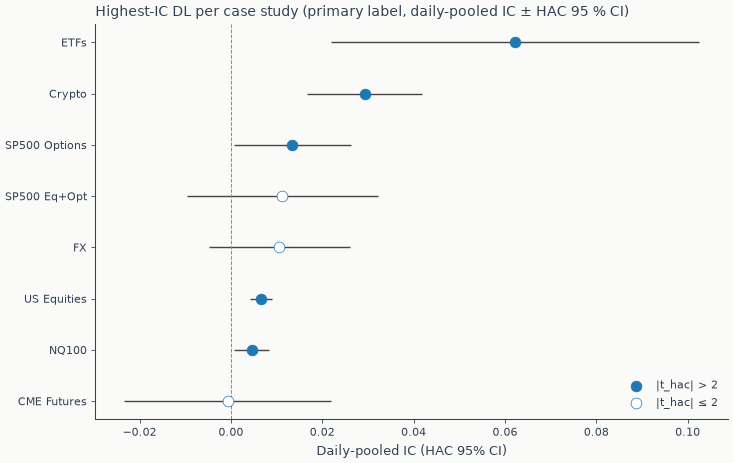

In [8]:
fig, _ = plot_cross_cs_forest(
    dl_rank1,
    family=FAMILY,
    title="Highest-IC DL per case study (primary label, daily-pooled IC ± HAC 95 % CI)",
)
fig.show()

In [9]:
n_dl_total = dl_rank1.height
n_sig = int((dl_rank1["ic_t_hac"].abs() > 2.0).sum())
print(f"DL CI excludes zero ({{|t_HAC|>2}}) on {n_sig} of {n_dl_total} DL-covered case studies.")

DL CI excludes zero ({|t_HAC|>2}) on 5 of 8 DL-covered case studies.


The IC CI excludes zero with margin ($|t_{HAC}| > 2$) on five of the eight
DL-covered case studies: ETFs, Crypto, NASDAQ-100, SP500 Options, and US Equities.
NASDAQ-100 sits at $t_{HAC} = 2.32$ with its CI lower bound at 0.0007, just
clearing zero. CME Futures, SP500 Eq+Opt, and
FX remain CI-overlap-zero regimes for cross-sectional rank prediction even
with sequence models. The selected operating point varies across
architectures: NLinear is the highest-IC choice on four panels (ETFs,
Crypto, NASDAQ-100, FX); LSTM on two (CME Futures, US Equities); PatchTST
on two (SP500 Eq+Opt at $t_{HAC} = 1.06$, SP500 Options at $t_{HAC} =
2.07$). The cross-CS coverage of LSTM and NLinear lets every panel include
at least one of those two as a candidate.

## 3. Within-Family Comparison

Three subsections trace the architecture grid: the highest IC by architecture
inside each case study (3a), the aggregate count of which architecture
achieves the highest IC (3b), and the per-checkpoint IC trajectory of the
highest-IC configuration on each case study (3c).

### 3a. Architecture × case-study heatmap

Within each case study, the highest IC achieved by each architecture is
shown as a heatmap cell. Cells are blank where the architecture was not
trained on that case study — coverage gaps remain visible.

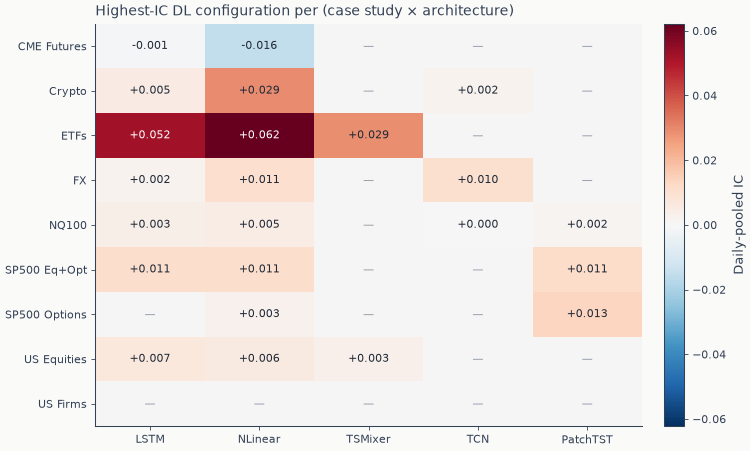

In [10]:
arch_cols = all_archs_sorted
cs_labels = avail_pivot["short_name"].to_list()
matrix_values = avail_pivot.select(arch_cols).to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
finite_vals = matrix_values[np.isfinite(matrix_values.astype(float))]
vmax = float(np.nanmax(np.abs(finite_vals))) if finite_vals.size else 0.05
masked = np.ma.array(matrix_values.astype(float), mask=~np.isfinite(matrix_values.astype(float)))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="#f5f5f5")
im = ax.imshow(masked, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(arch_cols)))
ax.set_xticklabels(arch_cols)
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(arch_cols)):
        v = matrix_values[i, j]
        if v is not None and np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(v) > 0.6 * vmax else "#1f2937",
            )
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="#9ca3af")
ax.set_title("Highest-IC DL configuration per (case study × architecture)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Daily-pooled IC")
fig.show()

Inside the columns where coverage is full (LSTM, NLinear), the IC ordering
is heterogeneous across panels: NLinear's affine identity-residual
parameterization tops Crypto, ETFs, NASDAQ-100, and FX; LSTM tops CME
Futures and US Equities. PatchTST tops the highest-IC slot on the two
panels where it appears: SP500 Eq+Opt, where it edges out both LSTM and
NLinear, and SP500 Options, where LSTM has no covered configuration so it
leads NLinear alone. The remaining partial-coverage architectures (TSMixer,
TCN) do not top any panel at the primary label.

### 3b. Aggregate: which architecture achieves the highest IC most often

Counting across DL-covered case studies, how often does each architecture
achieve the highest IC at the primary label? The bar is annotated with the
mean IC of the case studies where the architecture achieves the highest IC
(the table above also reports the min/max across those case studies) —
magnitudes matter as much as counts.

In [11]:
arch_top_counts = (
    dl_rank1_display.group_by("architecture")
    .agg(
        n_cs_with_highest_ic=pl.col("case_study").len(),
        ic_mean=pl.col("ic_mean_daily").mean(),
        ic_min=pl.col("ic_mean_daily").min(),
        ic_max=pl.col("ic_mean_daily").max(),
    )
    .sort("n_cs_with_highest_ic", descending=True)
)
print("Architecture achieving the highest IC at the primary label (count across DL-covered CSs):")
arch_top_counts

Architecture achieving the highest IC at the primary label (count across DL-covered CSs):


architecture,n_cs_with_highest_ic,ic_mean,ic_min,ic_max
str,u32,f64,f64,f64
"""NLinear""",4,0.026664,0.00456,0.062197
"""PatchTST""",2,0.012367,0.011263,0.013471
"""LSTM""",2,0.002937,-0.00071,0.006584


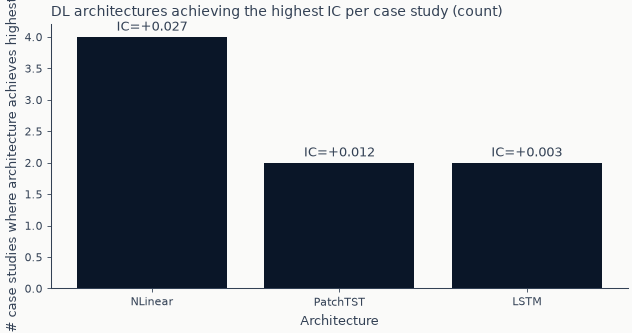

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(
    arch_top_counts["architecture"].to_list(),
    arch_top_counts["n_cs_with_highest_ic"].to_list(),
    color=COLORS.get("blue", "#1f77b4"),
)
ax.set_xlabel("Architecture")
ax.set_ylabel("# case studies where architecture achieves highest IC")
ax.set_title("DL architectures achieving the highest IC per case study (count)")
for i, (n, ic) in enumerate(
    zip(
        arch_top_counts["n_cs_with_highest_ic"].to_list(),
        arch_top_counts["ic_mean"].to_list(),
    )
):
    ax.text(i, n + 0.1, f"IC={ic:+.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.show()

NLinear is the highest-IC architecture on four of eight DL-covered case
studies; LSTM on two; PatchTST on two. The two panels where LSTM tops are
the ones where temporal recurrence over the sequence carries
discriminative content beyond what an affine identity-residual
decomposition extracts — CME Futures (term-structure dynamics, though the
IC point estimate is near zero) and US Equities (broad cross-section with
daily horizon). PatchTST tops SP500 Eq+Opt and SP500 Options. TSMixer and
TCN achieve the highest IC on no DL-covered case study at the primary
label, though their per-architecture IC values sit within one CI
half-width of the topping configuration on several panels.

### 3c. Checkpoint dynamics

For each case study's highest-IC DL configuration, the per-checkpoint
(epoch) IC trajectory is plotted with the IQR band across folds. Peaked
curves identify clear early-stopping value; flat curves indicate the
optimization landscape is benign across the budget.

In [13]:
ckpt_frames = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    rank1_row = dl_rank1.filter(pl.col("case_study") == cs)
    if rank1_row.is_empty():
        continue
    cfg = rank1_row.row(0, named=True)["config_name"]
    fm = load_fold_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if fm.is_empty():
        continue
    sub = fm.filter((pl.col("config_name") == cfg) & pl.col("checkpoint_value").is_not_null())
    if sub.is_empty():
        continue
    agg = (
        sub.group_by("checkpoint_value")
        .agg(
            ic_median=pl.col("ic").median(),
            ic_q25=pl.col("ic").quantile(0.25),
            ic_q75=pl.col("ic").quantile(0.75),
        )
        .sort("checkpoint_value")
    )
    if agg.height < 2:
        continue
    ckpt_frames.append(
        agg.with_columns(
            pl.lit(SHORT_NAMES[cs]).alias("short_name"),
            pl.lit(architecture(cfg)).alias("architecture"),
        )
    )

ckpt_df = pl.concat(ckpt_frames) if ckpt_frames else pl.DataFrame()

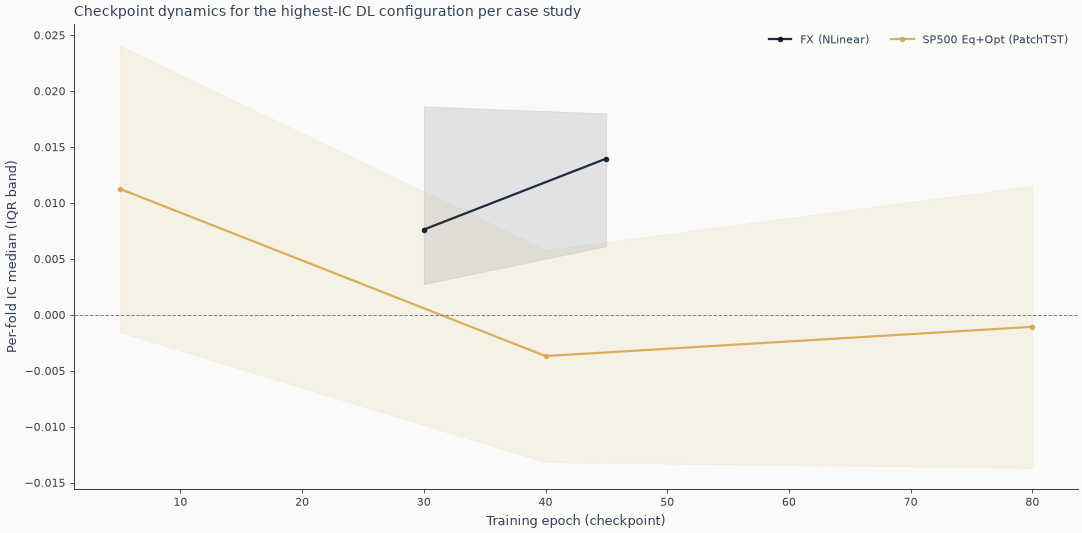

In [14]:
if not ckpt_df.is_empty():
    fig, ax = plt.subplots(figsize=(11, 5.5))
    palette = [
        COLORS["blue"],
        COLORS["amber"],
        COLORS["copper"],
        COLORS["positive"],
        COLORS["negative"],
        COLORS["neutral"],
        COLORS["slate"],
        COLORS["amber_light"],
    ]
    cs_sorted = sorted(ckpt_df["short_name"].unique().to_list())
    for i, cs in enumerate(cs_sorted):
        sub = ckpt_df.filter(pl.col("short_name") == cs).sort("checkpoint_value")
        x = sub["checkpoint_value"].to_numpy()
        med = sub["ic_median"].to_numpy()
        q25 = sub["ic_q25"].to_numpy()
        q75 = sub["ic_q75"].to_numpy()
        color = palette[i % len(palette)]
        arch = sub["architecture"].to_list()[0]
        ax.fill_between(x, q25, q75, color=color, alpha=0.10)
        ax.plot(
            x,
            med,
            "o-",
            color=color,
            label=f"{cs} ({arch})",
            linewidth=1.6,
            markersize=4,
            alpha=0.9,
        )
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Training epoch (checkpoint)")
    ax.set_ylabel("Per-fold IC median (IQR band)")
    ax.set_title("Checkpoint dynamics for the highest-IC DL configuration per case study")
    ax.legend(loc="best", frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    fig.show()
else:
    print("No DL checkpoint data available.")

Trajectories cluster into two regimes: case studies whose median IC peaks
at the first or second checkpoint and decays thereafter (NASDAQ-100, SP500
Options, Crypto), and case studies whose median IC keeps drifting upward
across the budget (FX, CME Futures, US Equities). The IQR bands shrink as
more folds enter the average; on Crypto and SP500 Options the band stays
wide throughout because only two folds carry checkpoint data. The
trajectory shape, not just the level, supports the early-stopping schedule
choice already in the per-architecture training notebooks.

## 4. Stability and Uncertainty

Daily-pooled IC with HAC CI is the headline metric. Per-fold IC is the
stability diagnostic; conformal coverage is the calibration diagnostic.

### 4a. Per-fold IC distribution

For each DL-covered case study, the per-fold IC distribution of the highest-
IC configuration is shown as a box-plus-scatter, sorted left-to-right by
headline IC.

In [15]:
dl_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family=FAMILY)
dl_fold_summary = (
    dl_fold.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC DL configuration (primary label):")
dl_fold_summary

Per-fold IC summary for the highest-IC DL configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""etfs""","""ETFs""",8,0.042912,0.05648,0.875
"""crypto_perps_funding""","""Crypto""",2,0.029333,0.007233,1.0
"""fx_pairs""","""FX""",8,0.013962,0.012856,0.875
"""sp500_options""","""SP500 Options""",2,0.013471,0.000101,1.0
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.011263,0.01811,0.5
"""us_equities_panel""","""US Equities""",16,0.008686,0.005072,0.8125
"""nasdaq100_microstructure""","""NQ100""",2,0.00456,0.004429,1.0
"""cme_futures""","""CME Futures""",5,-0.009006,0.026707,0.4


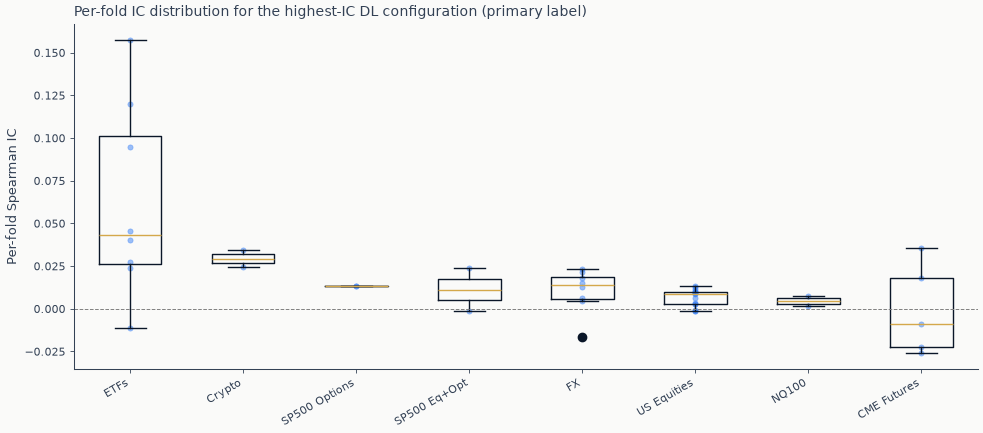

In [16]:
order = dl_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
fig, _ = plot_per_fold_violin(
    dl_fold,
    order=order,
    title="Per-fold IC distribution for the highest-IC DL configuration (primary label)",
)
fig.show()

Fold-IC distributions track the headline panel-by-panel: case studies
whose daily-pooled CI excludes zero (ETFs 0.875, Crypto 1.0, SP500 Options
1.0, US Equities 0.81 positive-fold share) also carry positive-fold
majorities, as does NASDAQ-100 (1.0) at the $t_{HAC} = 2.0$ boundary;
SP500 Eq+Opt (0.50) and CME Futures (0.40) straddle zero. The fold count
is uneven across case studies (2–16 folds depending on the
per-architecture CV schedule); narrow-fold panels make per-fold spread
less informative as a stability diagnostic than the daily-pooled HAC CI.

### 4b. Conformal coverage at the 90 % nominal level

Inductive split conformal calibrates a symmetric absolute-residual
quantile on fold 0 and measures empirical coverage on the remaining folds
at each nominal level. A well-calibrated DL signal sits near the diagonal
(empirical coverage = nominal level); points below the diagonal indicate
the prediction interval is too narrow, points above indicate it is too
wide. Per-CS interval width is reported in standard-deviation units of
the actual return.

In [17]:
conformal_rows = []
for cs in CASE_STUDY_IDS:
    df = conformal_coverage_diagnostic(cs, families=[FAMILY])
    if df.is_empty():
        continue
    sub = df.filter(pl.col("nominal_level") == CONFORMAL_LEVEL)
    if sub.is_empty():
        continue
    r = sub.row(0, named=True)
    conformal_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            "config_name": r["config_name"],
            "architecture": architecture(r["config_name"]),
            "nominal_level": r["nominal_level"],
            "empirical_coverage": r["empirical_coverage"],
            "interval_width_frac_std": r["mean_interval_width_frac_std"],
            "n_test": r["n_test"],
        }
    )

conformal_df = pl.DataFrame(conformal_rows).sort("short_name")
print(f"Inductive split-conformal coverage at the {CONFORMAL_LEVEL:.0%} nominal level:")
conformal_df.select(
    "short_name",
    "architecture",
    pl.col("empirical_coverage").round(3).alias("empirical_cov"),
    pl.col("interval_width_frac_std").round(3).alias("width_frac_std"),
    "n_test",
)

Inductive split-conformal coverage at the 90% nominal level:


short_name,architecture,empirical_cov,width_frac_std,n_test
str,str,f64,f64,i64
"""CME Futures""","""LSTM""",0.904,3.785,30726
"""Crypto""","""NLinear""",0.7,5.434,15071
"""ETFs""","""NLinear""",0.865,2.737,165564
"""FX""","""NLinear""",0.823,7.197,36120
"""NQ100""","""NLinear""",0.025,4.358,3269162
"""SP500 Eq+Opt""","""PatchTST""",0.978,3.829,105286
"""SP500 Options""","""PatchTST""",0.963,2.764,75004
"""US Equities""","""LSTM""",0.848,2.319,6199417


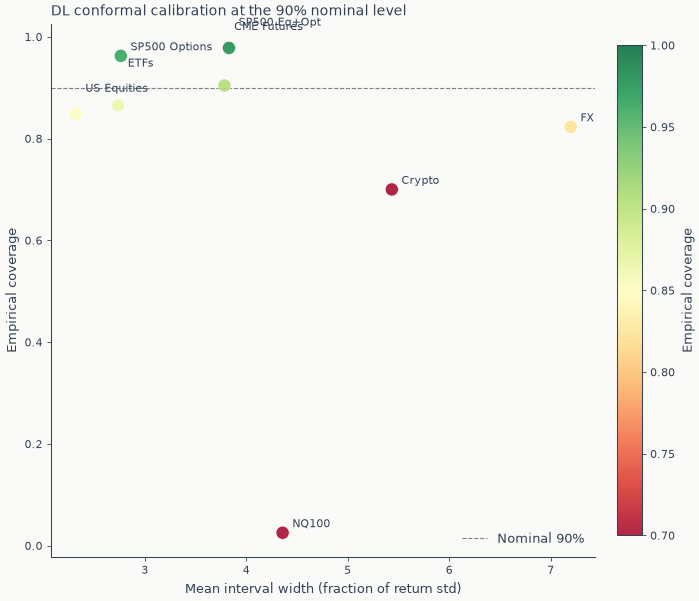

In [18]:
if not conformal_df.is_empty():
    fig, ax = plt.subplots(figsize=(7, 6))
    emp = conformal_df["empirical_coverage"].to_numpy()
    width = conformal_df["interval_width_frac_std"].to_numpy()
    names = conformal_df["short_name"].to_list()

    sc = ax.scatter(
        width,
        emp,
        s=90,
        alpha=0.85,
        edgecolor="white",
        c=emp,
        cmap="RdYlGn",
        vmin=0.7,
        vmax=1.0,
        zorder=3,
    )
    # Deconflict overlapping labels by staggering vertical offsets in screen
    # points: for points whose y differs by less than `y_tol` (data units),
    # add an extra 12 px per label in ascending-y order.
    y_tol = 0.04
    order = sorted(range(len(names)), key=lambda i: emp[i])
    y_offsets_pt = [4] * len(names)
    last_y_data = -1e9
    last_off = 4
    for i in order:
        if emp[i] - last_y_data < y_tol:
            y_offsets_pt[i] = last_off + 12
        else:
            y_offsets_pt[i] = 4
        last_off = y_offsets_pt[i]
        last_y_data = emp[i]
    for i, n in enumerate(names):
        ax.annotate(
            n,
            (width[i], emp[i]),
            textcoords="offset points",
            xytext=(7, y_offsets_pt[i]),
            fontsize=8,
        )
    ax.axhline(
        CONFORMAL_LEVEL,
        color="gray",
        linewidth=0.8,
        linestyle="--",
        label=f"Nominal {CONFORMAL_LEVEL:.0%}",
    )
    ax.set_xlabel("Mean interval width (fraction of return std)")
    ax.set_ylabel("Empirical coverage")
    ax.set_title(f"DL conformal calibration at the {CONFORMAL_LEVEL:.0%} nominal level")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.04, label="Empirical coverage")
    fig.show()

Empirical coverage at the 90 % nominal level is heterogeneous across the
DL-covered case studies. Three panels (CME Futures 0.90, ETFs 0.87, US
Equities 0.85) sit close to nominal; SP500 Eq+Opt and SP500 Options
over-cover (0.96–0.98); Crypto under-covers at 0.70 with a wide interval
(5.4 σ); FX also under-covers, at 0.82, with a very wide interval (7.2 σ); and
NASDAQ-100 collapses to 0.025 empirical coverage. The split-conformal
procedure here uses fold 0 as the calibration set and the remaining folds
as the test set: on panels where fold 0's residual distribution is not
representative of subsequent folds (regime change, intraday concentration
of fold-0 windows), the calibrated quantile carries forward poorly. The
cross-CS read is that single-fold inductive calibration is not robust on
the highest-IC DL signal — Mondrian conformal or full split-conformal across
multiple calibration folds would be the next step before claiming
operational coverage guarantees.

## 5. DL versus Tabular Baselines

The DL family enters a contested space — for every case study it is
compared to the highest-IC tabular configuration across linear, GBM, and
TabM. Two views: the DL-vs-highest-IC-tabular delta with paired-fold
bootstrap CI (5a), and a "when does DL help?" diagnostic table linking
the delta to panel-level features (5b).

In [19]:
def family_rank1_collect(family: str) -> pl.DataFrame:
    df = collect_rank1_per_cs(CASE_STUDY_IDS, family=family)
    if df.is_empty():
        return pl.DataFrame()
    return df.select(
        "case_study",
        "short_name",
        "config_name",
        pl.col("ic_mean_daily").alias(f"{family}_ic"),
    )


linear_rank1 = family_rank1_collect("linear")
gbm_rank1 = family_rank1_collect("gbm")
tabm_rank1 = family_rank1_collect("tabular_dl")
linear_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family="linear")
gbm_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family="gbm")
tabm_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family="tabular_dl")

In [20]:
delta_rows = []
rng = np.random.default_rng(SEED)
fold_lookup = {"linear": linear_fold, "gbm": gbm_fold, "tabular_dl": tabm_fold}
ic_lookup = {
    "linear": linear_rank1.rename({"linear_ic": "ic"}),
    "gbm": gbm_rank1.rename({"gbm_ic": "ic"}),
    "tabular_dl": tabm_rank1.rename({"tabular_dl_ic": "ic"}),
}

for cs in CASE_STUDY_IDS:
    dl_row = dl_rank1.filter(pl.col("case_study") == cs)
    if dl_row.is_empty():
        continue
    dl_ic = dl_row.row(0, named=True)["ic_mean_daily"]
    dl_arch = architecture(dl_row.row(0, named=True)["config_name"])

    # Baseline IC per family at this CS, and the one with the highest IC
    fam_to_ic = {}
    for fam in TABULAR_BASELINES:
        sub = ic_lookup[fam].filter(pl.col("case_study") == cs)
        if not sub.is_empty():
            fam_to_ic[fam] = sub.row(0, named=True)["ic"]
    if not fam_to_ic:
        continue
    best_fam = max(fam_to_ic, key=fam_to_ic.get)
    best_baseline_ic = fam_to_ic[best_fam]

    # Paired-fold delta: DL fold IC minus highest-IC-family fold IC
    g = dl_fold.filter(pl.col("case_study") == cs)
    l_ = fold_lookup[best_fam].filter(pl.col("case_study") == cs)
    paired = g.select("fold_id", pl.col("ic").alias("dl_ic")).join(
        l_.select("fold_id", pl.col("ic").alias("base_ic")),
        on="fold_id",
        how="inner",
    )
    if paired.height < 2:
        continue
    deltas = paired["dl_ic"].to_numpy() - paired["base_ic"].to_numpy()
    n = len(deltas)
    boot = rng.choice(deltas, size=(N_BOOT, n), replace=True).mean(axis=1)
    delta_rows.append(
        {
            "case_study": cs,
            "short_name": SHORT_NAMES[cs],
            "dl_arch": dl_arch,
            "dl_ic": dl_ic,
            "best_baseline_family": best_fam,
            "best_baseline_ic": best_baseline_ic,
            "n_paired_folds": n,
            "mean_delta": float(np.mean(deltas)),
            "boot_lo": float(np.percentile(boot, 2.5)),
            "boot_hi": float(np.percentile(boot, 97.5)),
        }
    )

delta_df = pl.DataFrame(delta_rows).sort("mean_delta", descending=True)
print("DL minus highest-IC tabular baseline (paired-fold bootstrap, primary label):")
delta_df.select(
    "short_name",
    "dl_arch",
    "best_baseline_family",
    pl.col("dl_ic").round(4).alias("dl"),
    pl.col("best_baseline_ic").round(4).alias("base"),
    "n_paired_folds",
    pl.col("mean_delta").round(4).alias("delta"),
    pl.col("boot_lo").round(4).alias("boot_lo"),
    pl.col("boot_hi").round(4).alias("boot_hi"),
)

DL minus highest-IC tabular baseline (paired-fold bootstrap, primary label):


short_name,dl_arch,best_baseline_family,dl,base,n_paired_folds,delta,boot_lo,boot_hi
str,str,str,f64,f64,i64,f64,f64,f64
"""Crypto""","""NLinear""","""gbm""",0.0293,0.011,2,0.0184,0.008,0.0287
"""ETFs""","""NLinear""","""linear""",0.0622,0.0535,8,0.0087,-0.0297,0.0499
"""FX""","""NLinear""","""tabular_dl""",0.0106,0.0067,8,0.0034,-0.0077,0.0198
"""SP500 Eq+Opt""","""PatchTST""","""tabular_dl""",0.0113,0.0114,2,-0.0001,-0.0147,0.0145
"""NQ100""","""NLinear""","""gbm""",0.0046,0.006,2,-0.0014,-0.0062,0.0034
"""SP500 Options""","""PatchTST""","""gbm""",0.0135,0.0182,2,-0.0047,-0.0192,0.0098
"""US Equities""","""LSTM""","""gbm""",0.0066,0.0318,16,-0.0252,-0.0307,-0.0208
"""CME Futures""","""LSTM""","""gbm""",-0.0007,0.0322,5,-0.0329,-0.0699,0.0149


### 5a. DL versus highest-IC tabular baseline — scatter

The scatter plots the highest-IC tabular baseline on the x-axis and the
highest-IC DL configuration on the y-axis, one point per case study.
Points above the diagonal indicate DL exceeds the highest-IC tabular
baseline; points below indicate the tabular baseline tops the DL signal.
Marker fill encodes whether the paired-fold bootstrap CI for the delta
excludes zero.

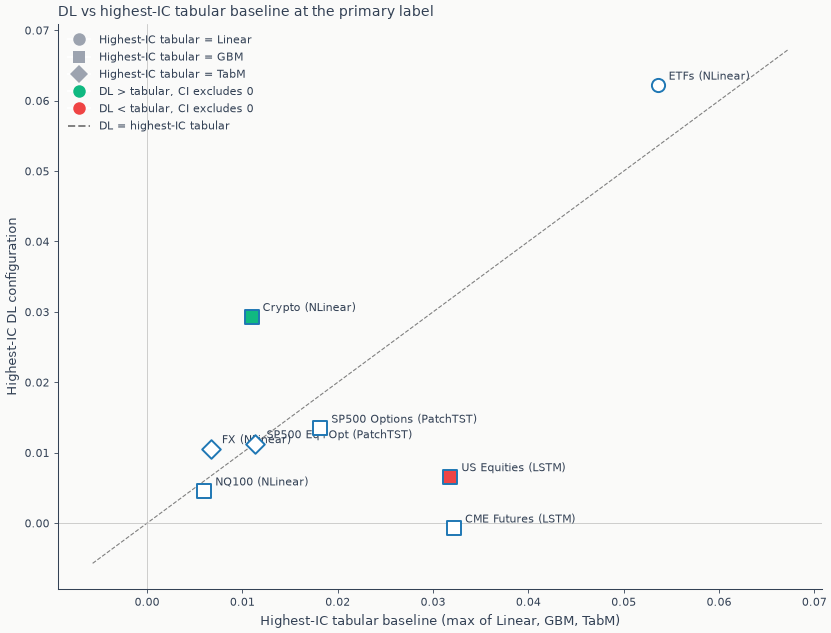

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
xs = delta_df["best_baseline_ic"].to_numpy()
ys = delta_df["dl_ic"].to_numpy()
los = delta_df["boot_lo"].to_numpy()
his = delta_df["boot_hi"].to_numpy()
sig = (los > 0) | (his < 0)
fams = delta_df["best_baseline_family"].to_list()
names = delta_df["short_name"].to_list()
arches = delta_df["dl_arch"].to_list()

fam_marker = {"linear": "o", "gbm": "s", "tabular_dl": "D"}
for x, y, name, arch, fam, s in zip(xs, ys, names, arches, fams, sig, strict=False):
    facecolor = (
        COLORS.get("positive", "#10B981")
        if s and y > x
        else COLORS.get("negative", "#EF4444")
        if s and y < x
        else "white"
    )
    ax.scatter(
        x,
        y,
        s=90,
        marker=fam_marker.get(fam, "o"),
        facecolor=facecolor,
        edgecolor="#1f77b4",
        linewidth=1.4,
        zorder=3,
    )
    ax.annotate(f"{name} ({arch})", (x, y), textcoords="offset points", xytext=(8, 4), fontsize=8)

lo = float(min(np.min(xs), np.min(ys))) - 0.005
hi = float(max(np.max(xs), np.max(ys))) + 0.005
ax.plot(
    [lo, hi], [lo, hi], color="gray", linewidth=0.8, linestyle="--", label="DL = highest-IC tabular"
)
ax.axhline(0, color="#bbb", linewidth=0.5)
ax.axvline(0, color="#bbb", linewidth=0.5)
ax.set_xlabel("Highest-IC tabular baseline (max of Linear, GBM, TabM)")
ax.set_ylabel("Highest-IC DL configuration")
ax.set_title("DL vs highest-IC tabular baseline at the primary label")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC tabular = Linear",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC tabular = GBM",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="#1f77b4",
        markersize=9,
        label="Highest-IC tabular = TabM",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS.get("positive", "#10B981"),
        markeredgecolor="#1f77b4",
        markersize=9,
        label="DL > tabular, CI excludes 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS.get("negative", "#EF4444"),
        markeredgecolor="#1f77b4",
        markersize=9,
        label="DL < tabular, CI excludes 0",
    ),
    Line2D([0], [0], color="gray", linestyle="--", label="DL = highest-IC tabular"),
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False, fontsize=8)
fig.tight_layout()
fig.show()

In [22]:
n_above = int((ys > xs).sum())
n_sig_above = int(((ys > xs) & sig).sum())
n_sig_below = int(((ys < xs) & sig).sum())
print(
    f"DL > tabular point estimate on {n_above}/{len(ys)} case studies; "
    f"paired-fold bootstrap CI excludes zero (DL above) on {n_sig_above}, "
    f"(DL below) on {n_sig_below}."
)

DL > tabular point estimate on 3/8 case studies; paired-fold bootstrap CI excludes zero (DL above) on 1, (DL below) on 1.


### 5b. When does DL help? Diagnostic table

The same delta cross-referenced with panel-level features: data frequency,
universe size (entities), and the highest-IC tabular family. The rows are
sorted by the bootstrap point-estimate of the DL-minus-tabular delta,
largest first.

In [23]:
diagnostic_rows = []
for r in delta_df.iter_rows(named=True):
    cs = r["case_study"]
    meta = DATASET_META.get(cs, {})
    diagnostic_rows.append(
        {
            "short_name": r["short_name"],
            "frequency": meta.get("frequency"),
            "entities": meta.get("entities"),
            "best_tabular": r["best_baseline_family"],
            "tab_ic": r["best_baseline_ic"],
            "dl_arch": r["dl_arch"],
            "dl_ic": r["dl_ic"],
            "delta": r["mean_delta"],
            "boot_lo": r["boot_lo"],
            "boot_hi": r["boot_hi"],
            "n_folds": r["n_paired_folds"],
        }
    )

diagnostic_df = pl.DataFrame(diagnostic_rows)
print("DL-help diagnostic table (sorted by paired-fold bootstrap delta, largest first):")
diagnostic_df.select(
    "short_name",
    "frequency",
    "entities",
    "best_tabular",
    "dl_arch",
    pl.col("tab_ic").round(4).alias("tab_ic"),
    pl.col("dl_ic").round(4).alias("dl_ic"),
    pl.col("delta").round(4).alias("delta"),
    pl.col("boot_lo").round(4).alias("ci_lo"),
    pl.col("boot_hi").round(4).alias("ci_hi"),
    "n_folds",
)

DL-help diagnostic table (sorted by paired-fold bootstrap delta, largest first):


short_name,frequency,entities,best_tabular,dl_arch,tab_ic,dl_ic,delta,ci_lo,ci_hi,n_folds
str,str,i64,str,str,f64,f64,f64,f64,f64,i64
"""Crypto""","""8-hourly""",21,"""gbm""","""NLinear""",0.011,0.0293,0.0184,0.008,0.0287,2
"""ETFs""","""Daily""",99,"""linear""","""NLinear""",0.0535,0.0622,0.0087,-0.0297,0.0499,8
"""FX""","""Daily""",20,"""tabular_dl""","""NLinear""",0.0067,0.0106,0.0034,-0.0077,0.0198,8
"""SP500 Eq+Opt""","""Daily""",638,"""tabular_dl""","""PatchTST""",0.0114,0.0113,-0.0001,-0.0147,0.0145,2
"""NQ100""","""15-min""",114,"""gbm""","""NLinear""",0.006,0.0046,-0.0014,-0.0062,0.0034,2
"""SP500 Options""","""Daily""",612,"""gbm""","""PatchTST""",0.0182,0.0135,-0.0047,-0.0192,0.0098,2
"""US Equities""","""Daily""",3199,"""gbm""","""LSTM""",0.0318,0.0066,-0.0252,-0.0307,-0.0208,16
"""CME Futures""","""Daily""",30,"""gbm""","""LSTM""",0.0322,-0.0007,-0.0329,-0.0699,0.0149,5


Reading the diagnostic table left to right, the bootstrap CI structure
tells the story. The DL-minus-tabular delta is credibly positive (CI
excludes zero above) on Crypto only — DL adds incremental signal where
the highest-IC tabular baseline (GBM at +0.011 IC) is itself near zero.
The delta is credibly negative (CI excludes zero below) on US Equities
— the highest-IC tabular baseline is GBM at +0.032 IC, and LSTM's
+0.007 IC sits below it on every paired fold. On the remaining six
panels the bootstrap CI overlaps zero: DL is statistically
indistinguishable from the highest-IC tabular baseline on the same
fold set. Frequency is not a clean predictor of DL benefit (CME Futures
daily and Crypto 8-hourly both show large positive point estimates with
different CI widths). Universe size matters more — narrower universes
(FX, Crypto) limit DL's sample-efficiency advantage even where the
point estimate is positive.

## 6. Multi-Label Horizon View

DL training is single-horizon for most case studies (the per-architecture
notebooks use the case study's primary label only). The exceptions are
CME Futures (`fwd_ret_5d` primary plus `fwd_ret_21d`) and US Equities
(`fwd_ret_1d` primary plus `fwd_ret_5d`). The remaining case studies
appear as a single-point series and are excluded from the figure rather
than padded.

DL multi-label horizon coverage: 10 (CS, label) cells across 8 case studies.


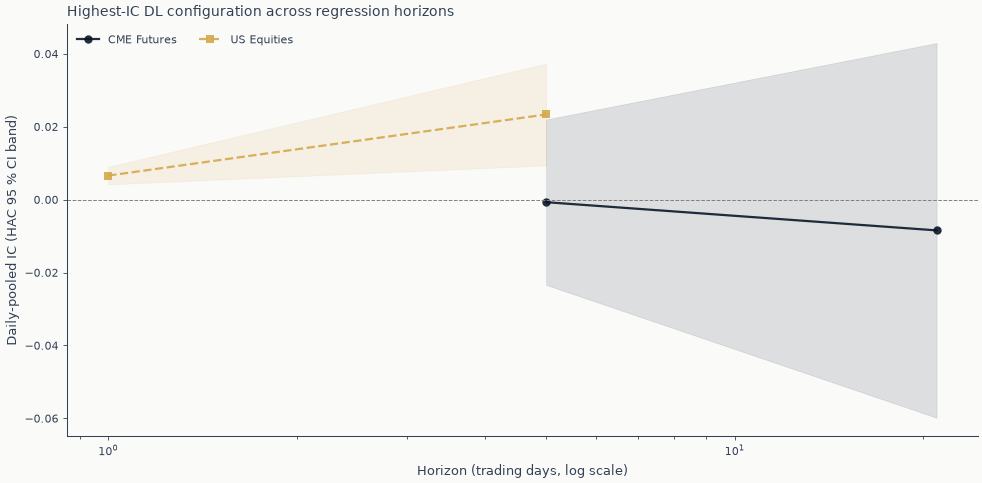

In [24]:
def regression_labels(cs: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[FAMILY])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None and (lbl.startswith("fwd_ret_") or lbl == "ret_to_expiry")
    ]


dl_horizon = collect_multi_label_per_cs(CASE_STUDY_IDS, family=FAMILY, labels=regression_labels)
print(
    f"DL multi-label horizon coverage: {dl_horizon.height} (CS, label) cells "
    f"across {dl_horizon['case_study'].n_unique() if not dl_horizon.is_empty() else 0} case studies."
)

multi_horizon_cs = (
    dl_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
if multi_horizon_cs:
    fig, _ = plot_multi_label_horizon(
        dl_horizon,
        title="Highest-IC DL configuration across regression horizons",
    )
    fig.show()
else:
    print(
        "No case study has ≥2 DL labels — horizon comparison is degenerate at the registry "
        "snapshot used here."
    )

Where CME Futures and US Equities carry ≥2 DL horizons, the IC profile
across horizons is panel-specific; cross-CS horizon claims for the DL
family require additional training coverage at non-primary labels and
remain out of scope for this snapshot.

## 7. Architectural Patterns

The five architectures map to four classes — recurrent (LSTM), MLP-style
(NLinear, TSMixer), convolutional (TCN), attention (PatchTST). For each
class, we read the highest IC achieved on each case study where the class
has at least one trained configuration.

In [25]:
class_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = load_metrics_from_registry(cs, label=primary, families=[FAMILY])
    if df.is_empty():
        continue
    df = (
        df.with_columns(
            architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8),
        )
        .with_columns(
            arch_class=pl.col("architecture").replace_strict(ARCH_CLASS, default=None),
        )
        .filter(pl.col("ic_mean_daily").is_not_null() & pl.col("arch_class").is_not_null())
    )
    if df.is_empty():
        continue
    by_class = (
        df.sort("ic_mean_daily", descending=True)
        .group_by("arch_class")
        .first()
        .select("arch_class", "ic_mean_daily", "ic_ci_lo", "ic_ci_hi", "ic_t_hac", "config_name")
    )
    for r in by_class.iter_rows(named=True):
        class_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "arch_class": r["arch_class"],
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r["ic_ci_lo"],
                "ic_ci_hi": r["ic_ci_hi"],
                "ic_t_hac": r["ic_t_hac"],
            }
        )
class_df = pl.DataFrame(class_rows)
print("Highest IC per (case study × architecture class):")
class_df.sort(["short_name", "arch_class"]).select(
    "short_name",
    "arch_class",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
)

Highest IC per (case study × architecture class):


short_name,arch_class,config_name,ic,t_hac
str,str,str,f64,f64
"""CME Futures""","""MLP-style""","""nlinear""",-0.0155,-1.04
"""CME Futures""","""recurrent""","""lstm_h64""",-0.0007,-0.06
"""Crypto""","""MLP-style""","""nlinear""",0.0293,4.58
"""Crypto""","""convolutional""","""tcn""",0.0024,0.37
"""Crypto""","""recurrent""","""lstm_h64""",0.0051,0.79
"""ETFs""","""MLP-style""","""nlinear""",0.0622,3.02
"""ETFs""","""recurrent""","""lstm_h64""",0.0521,2.37
"""FX""","""MLP-style""","""nlinear""",0.0106,1.34
"""FX""","""convolutional""","""tcn""",0.0099,1.48


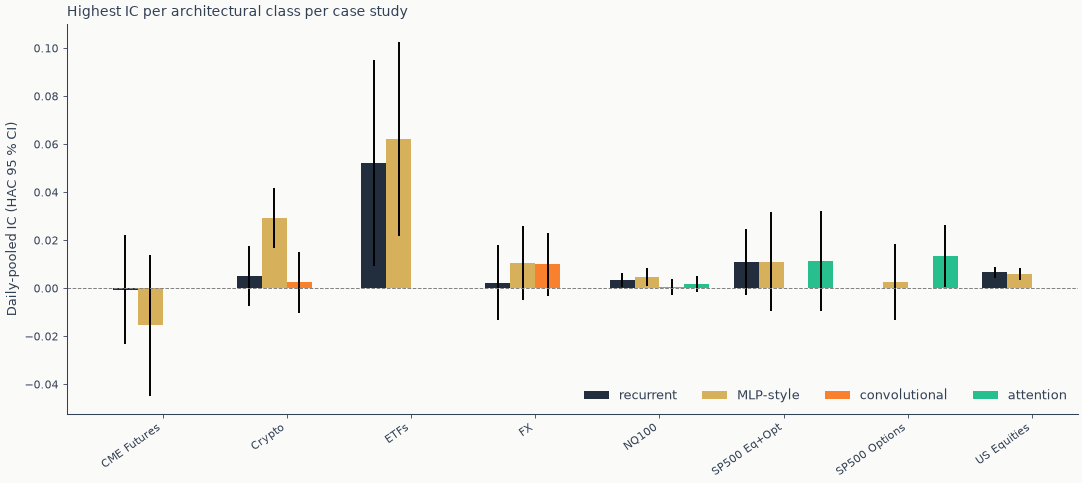

In [26]:
arch_classes = ["recurrent", "MLP-style", "convolutional", "attention"]
class_colors = {
    "recurrent": COLORS.get("blue", "#3B82F6"),
    "MLP-style": COLORS.get("amber", "#F59E0B"),
    "convolutional": COLORS.get("orange", "#F97316"),
    "attention": COLORS.get("positive", "#10B981"),
}

cs_order_class = sorted(class_df["short_name"].unique().to_list())
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cs_order_class))
width = 0.20
for i, cls in enumerate(arch_classes):
    sub = class_df.filter(pl.col("arch_class") == cls)
    ic = []
    err_lo = []
    err_hi = []
    for cs in cs_order_class:
        row = sub.filter(pl.col("short_name") == cs)
        if row.height == 0:
            ic.append(np.nan)
            err_lo.append(0.0)
            err_hi.append(0.0)
        else:
            r = row.row(0, named=True)
            ic.append(r["ic_mean_daily"])
            err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
            err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
    ic_a = np.array(ic, dtype=float)
    ax.bar(
        x + (i - 1.5) * width,
        ic_a,
        width=width,
        yerr=np.vstack([err_lo, err_hi]),
        capsize=2,
        color=class_colors[cls],
        alpha=0.9,
        label=cls,
    )
ax.set_xticks(x)
ax.set_xticklabels(cs_order_class, rotation=35, ha="right")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("Highest IC per architectural class per case study")
ax.legend(frameon=False, fontsize=9, loc="best", ncol=4)
fig.tight_layout()
fig.show()

In [27]:
class_top_per_cs = (
    class_df.sort("ic_mean_daily", descending=True)
    .group_by("short_name")
    .first()
    .group_by("arch_class")
    .agg(n_cs_with_highest_ic=pl.col("short_name").len())
    .sort("n_cs_with_highest_ic", descending=True)
)
print("Architectural class achieving the highest IC per case study (count):")
class_top_per_cs

Architectural class achieving the highest IC per case study (count):


arch_class,n_cs_with_highest_ic
str,u32
"""MLP-style""",4
"""recurrent""",2
"""attention""",2


Aggregated by architectural class, the MLP-style class (NLinear, TSMixer)
achieves the highest IC on four of the eight DL-covered case studies. The
recurrent class (LSTM) tops two; the attention class (PatchTST) tops two
(SP500 Eq+Opt and SP500 Options). The convolutional class (TCN) does not
top any panel where it is trained. Per-CS IC values across classes sit
within one CI half-width on most panels — the architecture-class gap is
small relative to the per-CS noise band.

## Cross-CS Key Takeaways

- **Coverage**: DL covers eight of nine case studies (US Firms has no DL
  rows in the registry). NLinear is trained on all eight and LSTM on seven
  (all except SP500 Options); TCN, TSMixer, and PatchTST contribute partial
  coverage on three, two, and three panels respectively.
- **Significance**: five of eight DL-covered case studies clear
  $|t_{HAC}| > 2$ at the primary label — ETFs, Crypto, NASDAQ-100, SP500
  Options, and US Equities. NASDAQ-100 clears it at $t_{HAC} = 2.32$ (CI
  lower bound 0.0007); CME Futures, SP500 Eq+Opt, and FX remain CI-overlap-zero.
- **Architecture split**: NLinear achieves the highest IC on four panels,
  LSTM on two, PatchTST on two; TSMixer and TCN top no panel. Aggregated
  by class the MLP-style class achieves the highest IC on four panels,
  recurrent on two, attention on two — gaps small relative to per-CS noise.
- **DL vs the highest-IC tabular baseline, paired by fold**: the bootstrap
  CI excludes zero above on Crypto only and excludes zero below on US
  Equities only; the other six panels are statistically indistinguishable
  from their highest-IC tabular comparator on the same fold set.
- **Conformal calibration is heterogeneous**: at 90 % nominal coverage
  three case studies sit close to nominal, two over-cover (SP500 Eq+Opt
  and SP500 Options), and three diverge (Crypto, FX, NASDAQ-100) —
  multi-fold or Mondrian conformal is the natural next step before
  claiming operational coverage guarantees.

**Next**: Ch14 adds latent-factor models on the panels that satisfy the
dimensionality gate; Ch15 layers causal effects on top of the predictive
stack.